In [20]:
import pandas as pd
import numpy as np

df = pd.read_csv("youtube.csv",
                 engine='python',
                 on_bad_lines='skip')
print(df.head())
print(df.info())

   index     video_id trending_date  \
0      0  2kyS6SvSYSE      17.14.11   
1      1  1ZAPwfrtAFY      17.14.11   
2      2  5qpjK5DgCt4      17.14.11   
3      3  puqaWrEC7tY      17.14.11   
4      4  d380meD0W0M      17.14.11   

                                               title          channel_title  \
0                 WE WANT TO TALK ABOUT OUR MARRIAGE           CaseyNeistat   
1  The Trump Presidency: Last Week Tonight with J...        LastWeekTonight   
2  Racist Superman | Rudy Mancuso, King Bach & Le...           Rudy Mancuso   
3                   Nickelback Lyrics: Real or Fake?  Good Mythical Morning   
4                           I Dare You: GOING BALD!?               nigahiga   

   category_id publish_date      time_frame published_day_of_week  \
0           22   13/11/2017  17:00 to 17:59                Monday   
1           24   13/11/2017    7:00 to 7:59                Monday   
2           23   12/11/2017  19:00 to 19:59                Sunday   
3           24

In [21]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert trending_date to datetime
df['trending_date'] = pd.to_datetime(df['trending_date'], errors='coerce')

# Fill missing values
df.fillna("Not Available", inplace=True)

# Remove unnecessary column
df.drop(columns=['index'], inplace=True, errors='ignore')

print("Cleaned Data Shape:", df.shape)

/tmp/ipykernel_3495/3671576028.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['trending_date'] = pd.to_datetime(df['trending_date'], errors='coerce')
/tmp/ipykernel_3495/3671576028.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Not Available' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df.fillna("Not Available", inplace=True)


Cleaned Data Shape: (161470, 17)


In [22]:
from textblob import TextBlob

# Function
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

# Apply
df['sentiment_score'] = df['title'].apply(get_sentiment)

# Categorize
def label_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['sentiment_score'].apply(label_sentiment)

print(df[['title', 'sentiment']].head())

                                               title sentiment
0                 WE WANT TO TALK ABOUT OUR MARRIAGE   Neutral
1  The Trump Presidency: Last Week Tonight with J...   Neutral
2  Racist Superman | Rudy Mancuso, King Bach & Le...   Neutral
3                   Nickelback Lyrics: Real or Fake?  Negative
4                           I Dare You: GOING BALD!?   Neutral


In [23]:
import sqlite3

# Convert datetime → string
df['trending_date'] = df['trending_date'].astype(str)

# Connect
conn = sqlite3.connect("youtube.db")

# Insert into SQL
df.to_sql("youtube_data", conn, if_exists="replace", index=False)

print("Data inserted successfully!")

Data inserted successfully!


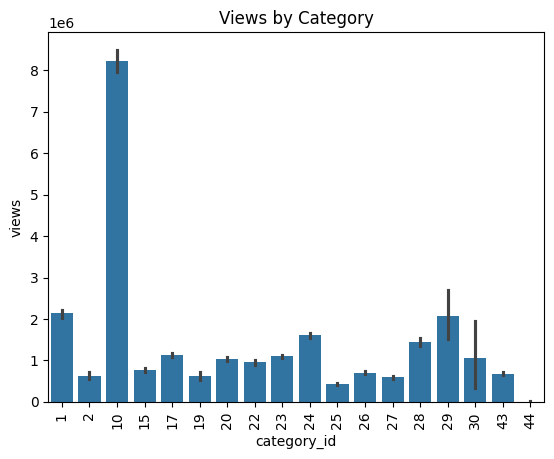

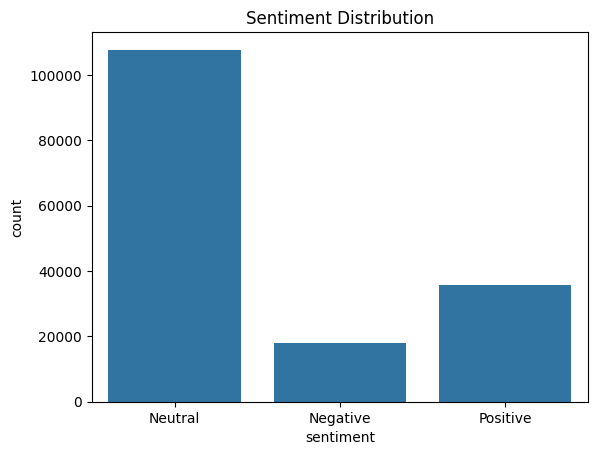

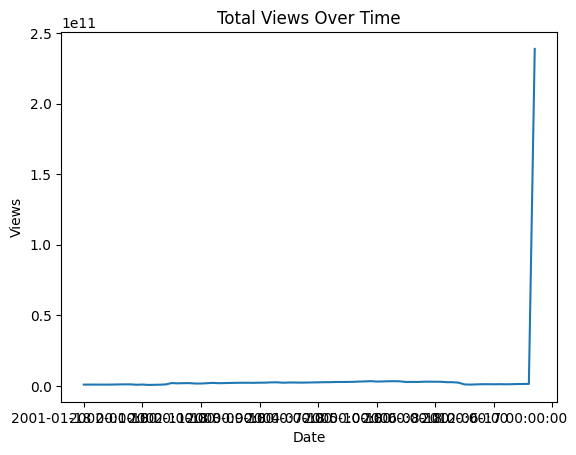

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Category vs Views
plt.figure()
sns.barplot(x='category_id', y='views', data=df)
plt.xticks(rotation=90)
plt.title("Views by Category")
plt.show()


# Sentiment Distribution
plt.figure()
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()


# Time Series (Trending Views Over Time)
plt.figure()
df.groupby('trending_date')['views'].sum().plot()
plt.title("Total Views Over Time")
plt.xlabel("Date")
plt.ylabel("Views")
plt.show()

In [25]:
trending_days = df.groupby('video_id').size().reset_index(name='days_trending')

df = df.merge(trending_days, on='video_id')

print(df[['video_id', 'days_trending']].head())

      video_id  days_trending
0  2kyS6SvSYSE             12
1  1ZAPwfrtAFY              9
2  5qpjK5DgCt4             11
3  puqaWrEC7tY              8
4  d380meD0W0M             10


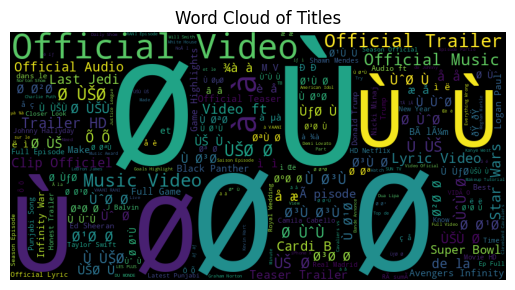

In [26]:
from wordcloud import WordCloud

text = " ".join(df['title'])

wc = WordCloud(width=800, height=400).generate(text)

plt.figure()
plt.imshow(wc)
plt.axis('off')
plt.title("Word Cloud of Titles")
plt.show()

In [27]:
import pandas as pd
import csv

df = pd.read_csv(
    "youtube.csv",
    engine='python',
    on_bad_lines='skip',
    encoding='utf-8'
)

# Basic cleaning
df.drop_duplicates(inplace=True)
df.fillna("Not Available", inplace=True)

# Fix date
df['trending_date'] = pd.to_datetime(df['trending_date'], errors='coerce')
df['trending_date'] = df['trending_date'].astype(str)


/tmp/ipykernel_3495/3830756757.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['trending_date'] = pd.to_datetime(df['trending_date'], errors='coerce')


Cleaned file saved!


In [28]:
df['trending_date'] = pd.to_datetime(
    df['trending_date'],
    format='%y.%d.%m',
    errors='coerce'
)

In [30]:
df = pd.read_csv(
    "youtube.csv",
    engine='python',
    on_bad_lines='skip'
)
df['trending_date'] = pd.to_datetime(
    df['trending_date'],
    format='%y.%d.%m'
)

print(df['trending_date'].head())

0   2017-11-14
1   2017-11-14
2   2017-11-14
3   2017-11-14
4   2017-11-14
Name: trending_date, dtype: datetime64[ns]


In [31]:
df.to_csv("youtube_cleaned.csv", index=False)